Set up libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
RANDOM_STATE = 42

Load the set and perform EDA

In [2]:
df = pd.read_csv("house_cleaned.csv")
df.head()
df.shape
df.columns.tolist()
df.info()
df.isnull().sum()
(df.isnull().sum() / len(df)) * 100
df.duplicated().sum()
df.describe()
df.describe(include='all')
df.select_dtypes(include=np.number).columns.tolist()
df.select_dtypes(include='object').columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_name    964 non-null    str    
 1   property_type    964 non-null    str    
 2   society          964 non-null    str    
 3   price            945 non-null    float64
 4   price_per_sqft   945 non-null    float64
 5   area             945 non-null    float64
 6   areaWithType     964 non-null    str    
 7   bedRoom          964 non-null    int64  
 8   bathroom         964 non-null    int64  
 9   balcony          964 non-null    str    
 10  additionalRoom   964 non-null    str    
 11  address          959 non-null    str    
 12  floorNum         945 non-null    float64
 13  facing           661 non-null    str    
 14  agePossession    964 non-null    str    
 15  nearbyLocations  848 non-null    str    
 16  description      964 non-null    str    
 17  furnishDetails   729 non-nu

['property_name',
 'property_type',
 'society',
 'areaWithType',
 'balcony',
 'additionalRoom',
 'address',
 'facing',
 'agePossession',
 'nearbyLocations',
 'description',
 'furnishDetails',
 'features',
 'rating']

House price Distribution

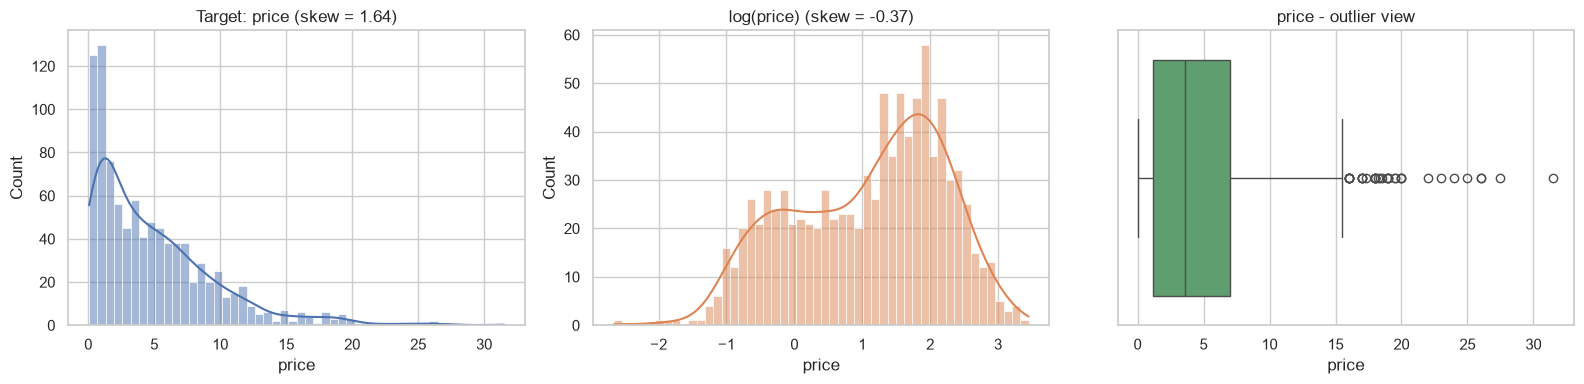

price: mean 5 | median 4 | std 5


In [3]:
import numpy as np
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["price"], bins=50, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title(f"Target: price (skew = {df['price'].skew():.2f})")
sns.histplot(np.log(df["price"]), bins=50, kde=True, ax=axes[1], color="#DD8452")
axes[1].set_title(f"log(price) (skew = {np.log(df['price']).skew():.2f})")
sns.boxplot(x=df["price"], ax=axes[2], color="#55A868")
axes[2].set_title("price - outlier view")
plt.tight_layout()
plt.show()
print("price: mean {:.0f} | median {:.0f} | std {:.0f}".format(df['price'].mean(), df['price'].median(), df['price'].std()))

Feature selection reasoning before modelling 

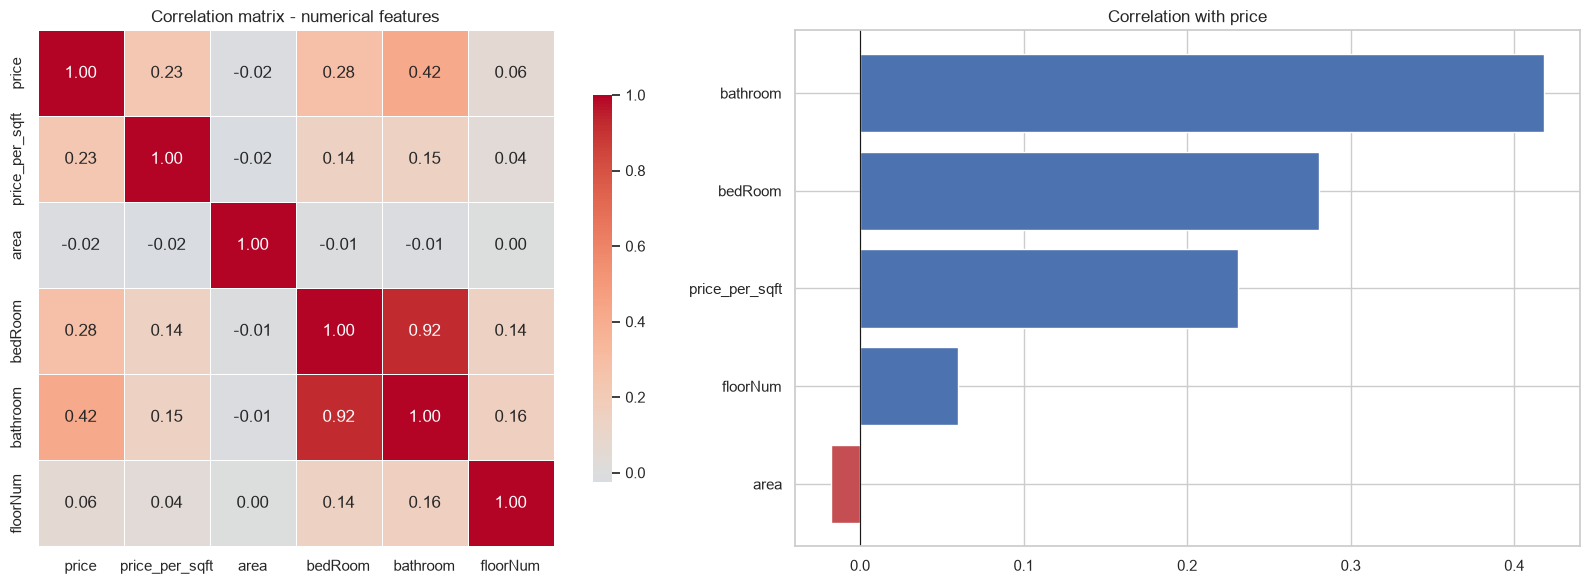

bathroom          0.418
bedRoom           0.280
price_per_sqft    0.231
floorNum          0.060
area             -0.018
Name: price, dtype: float64


In [4]:
import numpy as np
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[0], square=True,
            linewidths=.4, cbar_kws={"shrink":.75})
axes[0].set_title("Correlation matrix - numerical features")
price_col = [c for c in corr.columns if c.lower() == 'price'][0]
Price_corr = corr[price_col].drop(price_col).sort_values()
axes[1].barh(Price_corr.index, Price_corr.values,
             color=["#C44E52" if v < 0 else "#4C72B0" for v in Price_corr.values])
axes[1].set_title("Correlation with price")
axes[1].axvline(0, color="k", lw=.8)
plt.tight_layout()
plt.show()
print(corr[price_col].drop(price_col).sort_values(ascending=False).round(3))

Missing values and One-Hot Encoding 

In [5]:
df.columns = df.columns.str.strip().str.lower()
print("Columns:", df.columns.tolist())
data = df.copy()
if data['area'].dtype == 'object':
    data['area'] = data['area'].str.extract(r'(\d+\.?\d*)')[0].astype(float)
for col in ['area', 'bedroom', 'bathroom', 'price']:
    if col in data.columns:
        if data[col].dtype!= 'object':
            data[col] = data[col].fillna(data[col].median())
            print(f"{col} -> median se filled")
print("Nulls remaining:", data.isna().sum().sum())
cat_cols = data.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['property_name', 'society', 'areawithtype']]
print("Categorical columns:", cat_cols)
if len(cat_cols) > 0:
    data = pd.get_dummies(data, columns=cat_cols, drop_first=True, dtype=float)
    print(f"\ncolumns: {df.shape[1]} -> {data.shape[1]} after encoding")
else:
    print("No categorical to encode")
data.head()

Columns: ['property_name', 'property_type', 'society', 'price', 'price_per_sqft', 'area', 'areawithtype', 'bedroom', 'bathroom', 'balcony', 'additionalroom', 'address', 'floornum', 'facing', 'agepossession', 'nearbylocations', 'description', 'furnishdetails', 'features', 'rating']
area -> median se filled
bedroom -> median se filled
bathroom -> median se filled
price -> median se filled
Nulls remaining: 1120
Categorical columns: ['property_type', 'balcony', 'additionalroom', 'address', 'facing', 'agepossession', 'nearbylocations', 'description', 'furnishdetails', 'features', 'rating']

columns: 20 -> 3103 after encoding


,property_name,society,price,price_per_sqft,area,areawithtype,bedroom,bathroom,floornum,balcony_1,balcony_2,balcony_3,balcony_3+,additionalroom_others,additionalroom_pooja room,"additionalroom_pooja room,others","additionalroom_pooja room,servant room","additionalroom_pooja room,servant room,others","additionalroom_pooja room,servant room,store room","additionalroom_pooja room,servant room,study room,store room",...,"rating_['Environment5 out of 5', 'Lifestyle4 out of 5', 'Connectivity4 out of 5', 'Safety3 out of 5']","rating_['Environment5 out of 5', 'Lifestyle4 out of 5', 'Connectivity4 out of 5', 'Safety4 out of 5']","rating_['Environment5 out of 5', 'Lifestyle4 out of 5', 'Connectivity4 out of 5', 'Safety5 out of 5']","rating_['Environment5 out of 5', 'Lifestyle4 out of 5', 'Connectivity5 out of 5', 'Safety4 out of 5']","rating_['Environment5 out of 5', 'Lifestyle4 out of 5', 'Connectivity5 out of 5', 'Safety5 out of 5']","rating_['Environment5 out of 5', 'Lifestyle4.5 out of 5', 'Connectivity5 out of 5', 'Safety5 out of 5']","rating_['Environment5 out of 5', 'Lifestyle5 out of 5', 'Connectivity4 out of 5', 'Safety5 out of 5']","rating_['Environment5 out of 5', 'Lifestyle5 out of 5', 'Connectivity4.5 out of 5', 'Safety4.5 out of 5']","rating_['Environment5 out of 5', 'Lifestyle5 out of 5', 'Connectivity5 out of 5', 'Safety4 out of 5']","rating_['Environment5 out of 5', 'Lifestyle5 out of 5', 'Connectivity5 out of 5', 'Safety5 out of 5']","rating_['Environment5 out of 5', 'Safety4 out of 5', 'Lifestyle4 out of 5', 'Connectivity4 out of 5']","rating_['Environment5 out of 5', 'Safety4 out of 5', 'Lifestyle4 out of 5', 'Connectivity5 out of 5']","rating_['Environment5 out of 5', 'Safety4 out of 5', 'Lifestyle5 out of 5', 'Connectivity5 out of 5']","rating_['Environment5 out of 5', 'Safety4.5 out of 5', 'Lifestyle4 out of 5', 'Connectivity3.5 out of 5']","rating_['Environment5 out of 5', 'Safety4.5 out of 5', 'Lifestyle5 out of 5', 'Connectivity5 out of 5']","rating_['Environment5 out of 5', 'Safety5 out of 5', 'Lifestyle4 out of 5', 'Connectivity4 out of 5']","rating_['Environment5 out of 5', 'Safety5 out of 5', 'Lifestyle4 out of 5', 'Connectivity5 out of 5']","rating_['Environment5 out of 5', 'Safety5 out of 5', 'Lifestyle4.5 out of 5', 'Connectivity4 out of 5']","rating_['Environment5 out of 5', 'Safety5 out of 5', 'Lifestyle4.5 out of 5', 'Connectivity5 out of 5']","rating_['Environment5 out of 5', 'Safety5 out of 5', 'Lifestyle5 out of 5', 'Connectivity5 out of 5']"
0,5 Bedroom House for sale in Sector 70A Gurgaon,bptp visionnaire,5.25,20115.0,2610.0,Plot area 290(242.48 sq.m.),5,4,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5 Bedroom House for sale in Sector 21A Faridabad,independent,5.70,105751.0,539.0,Plot area 539(50.07 sq.m.),5,4,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10 Bedroom House for sale in Sushant Lok Phase 1,independent,2.10,38251.0,549.0,Plot area 61(51 sq.m.),10,10,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,21 Bedroom House for sale in Sector 54 Gurgaon,independent,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,12 Bedroom House for sale in Sushant Lok Phase 1,independent,3.00,53763.0,558.0,Plot area 62(51.84 sq.m.),12,12,5.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Train/test split and model training 

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
RANDOM_STATE = 42
def convert_price(x):
    try:
        if 'Crore' in str(x):
            return float(str(x).replace('Crore','').strip()) * 10000000
        if 'Lakh' in str(x):
            return float(str(x).replace('Lakh','').strip()) * 100000
        return float(x)
    except:
        return np.nan
if data['price'].dtype == 'object':
    data['price'] = data['price'].apply(convert_price)
cols_to_drop = ['property_name', 'society', 'areawithtype', 'price_per_sqft']
cols_to_drop = [c for c in cols_to_drop if c in data.columns]
data_model = data.drop(columns=cols_to_drop)
cat_cols = data_model.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols = [c for c in cat_cols if data_model[c].nunique() < 50] 
print("Encoding:", cat_cols)
data_model = pd.get_dummies(data_model, columns=cat_cols, drop_first=True, dtype=float)
data_model = data_model.dropna()
print(f"Final shape after cleaning: {data_model.shape}")
price_col = 'price'
X = data_model.drop(columns=price_col)
y = data_model[price_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape} | test: {X_test.shape}")
lin = LinearRegression()
lin.fit(X_train, y_train)
lin_log = LinearRegression()
lin_log.fit(X_train, np.log(y_train))
print("\nModels fitted: LinearRegression on price, and on log(Price)")
print("Intercept:", round(lin.intercept_, 2))

Encoding: []
Final shape after cleaning: (945, 3099)
Train: (756, 3098) | test: (189, 3098)

Models fitted: LinearRegression on price, and on log(Price)
Intercept: 3.08


Evaluation MSE,RMSE,R^2 

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
RANDOM_STATE = 42
def evaluate(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {"Model": name, "MSE": mse, "RMSE": rmse, 
            "MAE": mean_absolute_error(y_true, y_pred), 
            "R2": r2_score(y_true, y_pred), 
            "MAPE %": np.mean(np.abs((y_true - y_pred) / y_true)) * 100}
y_pred = lin.predict(X_test)
y_pred_log = np.exp(lin_log.predict(X_test))
rows = [evaluate("Linear Regression (Price)", y_test, y_pred), 
        evaluate("Linear Regression (Log Price)", y_test, y_pred_log)]
res = pd.DataFrame(rows).set_index("Model")
print(res.round(3).to_string(float_format=lambda v: f"{v:.3f}"))
cv = cross_val_score(LinearRegression(), X, y, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring="r2")
print(f"\n5-fold CV R2: {cv.mean():.4f} (+/- {cv.std():.4f})")
print(f"Train R2: {lin.score(X_train, y_train):.4f} | Test R2: {lin.score(X_test, y_test):.4f}")

                                 MSE  RMSE   MAE    R2  MAPE %
Model                                                         
Linear Regression (Price)     12.888 3.590 2.509 0.451 120.627
Linear Regression (Log Price) 20.256 4.501 2.580 0.137  79.838

5-fold CV R2: -1.9060 (+/- 4.6068)
Train R2: 0.4416 | Test R2: 0.4507


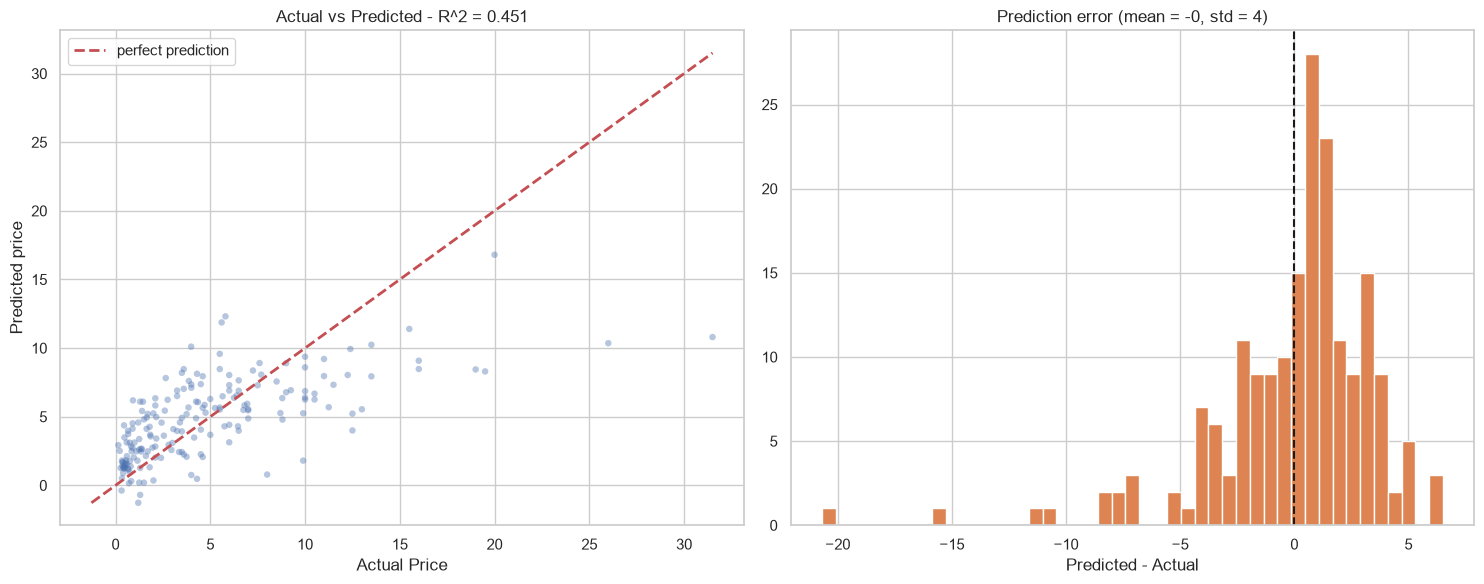

Predictions within 10% of actual: 7.9%
Predictions within 20% of actual: 18.0%


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].scatter(y_test, y_pred, alpha=.4, s=22, color="#4C72B0", edgecolor="none")
axes[0].plot(lims, lims, "r--", lw=2, label="perfect prediction")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted price")
axes[0].set_title(f"Actual vs Predicted - R^2 = {r2_score(y_test, y_pred):.3f}")
axes[0].legend()
err = y_pred - y_test
axes[1].hist(err, bins=45, color="#DD8452", edgecolor="white")
axes[1].axvline(0, color="k", ls="--")
axes[1].set_title(f"Prediction error (mean = {err.mean():.0f}, std = {err.std():.0f})")
axes[1].set_xlabel("Predicted - Actual")
plt.tight_layout()
plt.show()
within = lambda p: np.mean(np.abs(err) / y_test < p)
print(f"Predictions within 10% of actual: {within(.10):.1%}")
print(f"Predictions within 20% of actual: {within(.20):.1%}")

Residual analysis 

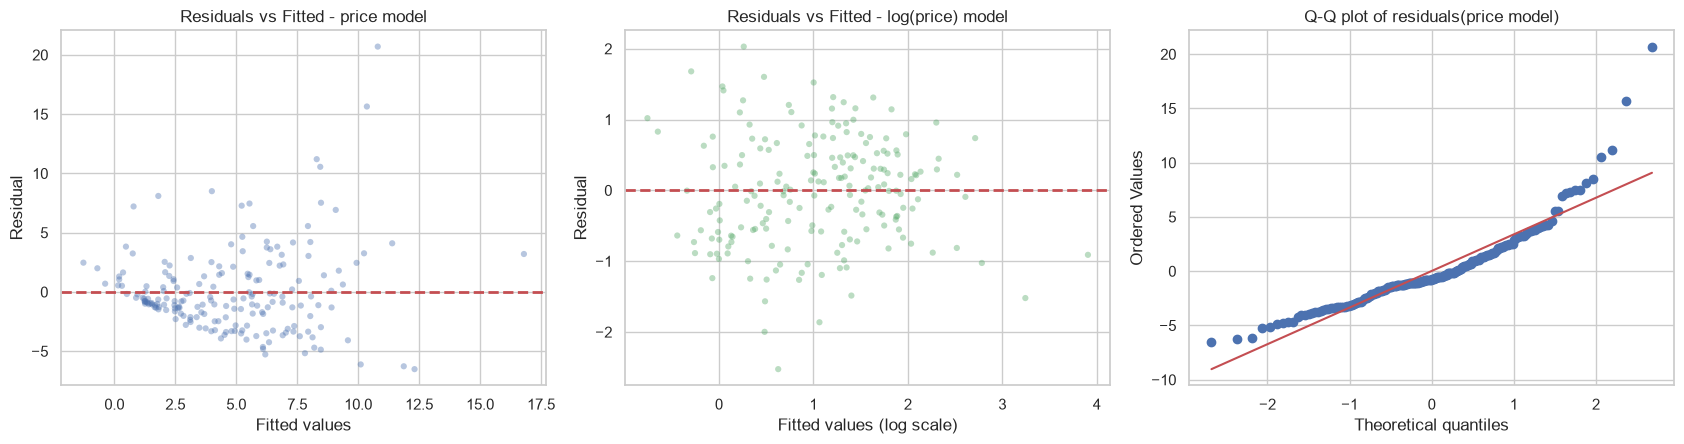

Residual mean: 0.0 (should be ~0)
Residual std : 3.6
Skew: 1.916 | Kurtosis: 6.950
Corr(|residual|, fitted): 0.441 (near 0 = homoscedastic)


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
residuals = y_test - y_pred
residuals_log = np.log(y_test) - lin_log.predict(X_test)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
axes[0].scatter(y_pred, residuals, alpha=.4, s=20, color="#4C72B0", edgecolor="none")
axes[0].axhline(0, color="r", ls="--", lw=2)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Fitted - price model")
axes[1].scatter(lin_log.predict(X_test), residuals_log, alpha=.4, s=20, color="#55A868", edgecolor="none")
axes[1].axhline(0, color="r", ls="--", lw=2)
axes[1].set_xlabel("Fitted values (log scale)")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Fitted - log(price) model")
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot of residuals(price model)")
plt.tight_layout()
plt.show()
print("Residual mean: {:,.1f} (should be ~0)".format(residuals.mean()))
print("Residual std : {:,.1f}".format(residuals.std()))
print("Skew: {:.3f} | Kurtosis: {:.3f}".format(stats.skew(residuals), stats.kurtosis(residuals)))
corr_rf = np.corrcoef(y_pred, np.abs(residuals))[0,1]
print(f"Corr(|residual|, fitted): {corr_rf:.3f} (near 0 = homoscedastic)")

Coefficient analysis 

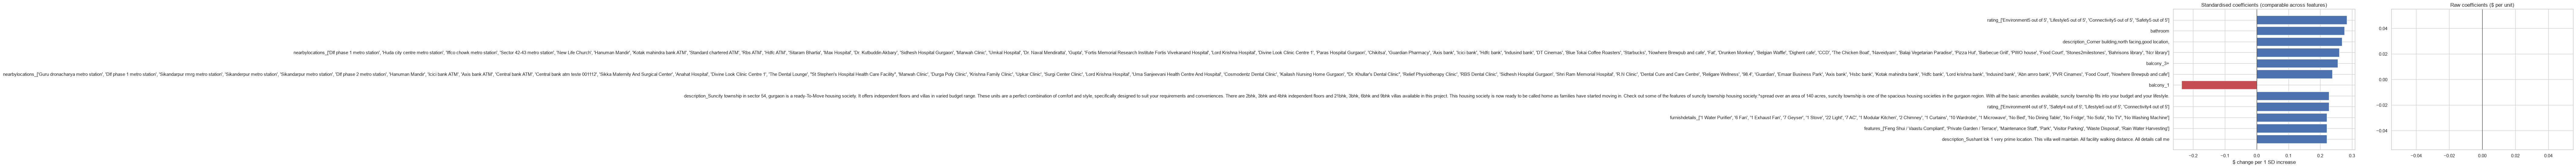

Regression Coefficients:


,feature,coefficient,std_coefficient,abs_std
3087,"rating_['Environment5 out of 5', 'Lifestyle5 o...",2.62,0.28,0.28
2,bathroom,0.92,0.28,0.28
1453,"description_Corner building,north facing,good ...",-0.01,0.27,0.27
790,"nearbylocations_['Dlf phase 1 metro station', ...",-0.01,0.26,0.26
7,balcony_3+,1.75,0.26,0.26
...,...,...,...,...
1027,"nearbylocations_['Sector metro station', 'Sect...",0.00,0.00,0.00
1025,"nearbylocations_['Sector metro station', 'Sect...",0.00,0.00,0.00
2530,"furnishdetails_['8 Wardrobe', '10 Fan', '1 Exh...",0.00,0.00,0.00
2529,"furnishdetails_['8 Fan', '7 Light', '5 AC', 'N...",0.00,0.00,0.00


In [10]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
coefs = pd.DataFrame({"feature": X.columns, "coefficient": lin.coef_})
# standardised coefficients: refit on z-scored features
scaler = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
lin_std = LinearRegression().fit(Xs_train, y_train)
coefs["std_coefficient"] = lin_std.coef_
coefs["abs_std"] = coefs["std_coefficient"].abs()
coefs = coefs.sort_values("abs_std", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
top = coefs.head(12).iloc[::-1]
axes[0].barh(top["feature"], top["std_coefficient"],
             color=["#C44E52" if v < 0 else "#4C72B0" for v in top["std_coefficient"]])
axes[0].axvline(0, color="k", lw=.8)
axes[0].set_title("Standardised coefficients (comparable across features)")
axes[0].set_xlabel("$ change per 1 SD increase")
raw = coefs.set_index("feature").loc[[c for c in ["Area","Bedrooms","Bathrooms","Parking","Stories","Age","City","Furnishing","Main Road","Guest Room","Basement","Water Supply","Air Conditioning","Preferred Tenant","Locality Rating","Price"] if c in coefs["feature"].values]]
axes[1].barh(raw.index, raw["coefficient"],
             color=["#C44E52" if v < 0 else "#55A868" for v in raw["coefficient"]])
axes[1].axvline(0, color="k", lw=.8)
axes[1].set_title("Raw coefficients ($ per unit)")
plt.tight_layout()
plt.show()
# Table
coefficient_table = coefs.copy()
print("Regression Coefficients:")
coefficient_table.round(2)

Bonus Ridge and lasso 

In [11]:
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.model_selection import KFold, cross_val_score
RANDOM_STATE = 42
alphas = np.logspace(-2, 4, 60)
pipelines = {
    "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge (CV alpha)": make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=5)),
    "Lasso (CV alpha)": make_pipeline(StandardScaler(), LassoCV(alphas=alphas, cv=5, random_state=RANDOM_STATE, max_iter=5000))
}
rows=[]
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    r = evaluate(name, y_test, pred)
    cvs = cross_val_score(pipe, X, y, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring="r2")
    r["CV R2"] = cvs.mean()
    rows.append(r)
comparison = pd.DataFrame(rows).set_index("Model")
print(comparison.round(4).to_string(float_format=lambda v: f"{v:.4f}"))
ridge_alpha = pipelines["Ridge (CV alpha)"].named_steps["ridgecv"].alpha_
lasso_model = pipelines["Lasso (CV alpha)"].named_steps["lassocv"]
lasso_alpha = lasso_model.alpha_
lasso_coef = lasso_model.coef_
print(f"\nChosen alpha - Ridge: {ridge_alpha:.3f} | Lasso: {lasso_alpha:.3f}")
print(f"Features zeroed out by Lasso: {(lasso_coef == 0).sum()} / {len(lasso_coef)}")
if (lasso_coef == 0).sum():
    print("Dropped:", list(X.columns[lasso_coef == 0]))

                      MSE   RMSE    MAE     R2   MAPE %   CV R2
Model                                                          
Linear Regression 14.5267 3.8114 2.5407 0.3809 138.6814  0.0823
Ridge (CV alpha)  14.4810 3.8054 2.5345 0.3828 138.4528 -0.0694
Lasso (CV alpha)  11.7453 3.4271 2.1935 0.4994  84.2190  0.1401

Chosen alpha - Ridge: 8.895 | Lasso: 0.026
Features zeroed out by Lasso: 1927 / 3098
Dropped: ['area', 'bedroom', 'floornum', 'balcony_2', 'balcony_3', 'additionalroom_pooja room,others', 'additionalroom_pooja room,servant room,others', 'additionalroom_pooja room,servant room,study room,store room', 'additionalroom_pooja room,store room', 'additionalroom_pooja room,store room,study room,servant room', 'additionalroom_pooja room,study room', 'additionalroom_pooja room,study room,others', 'additionalroom_pooja room,study room,servant room,others', 'additionalroom_pooja room,study room,store room,servant room', 'additionalroom_servant room,others', 'additionalroom_servant r

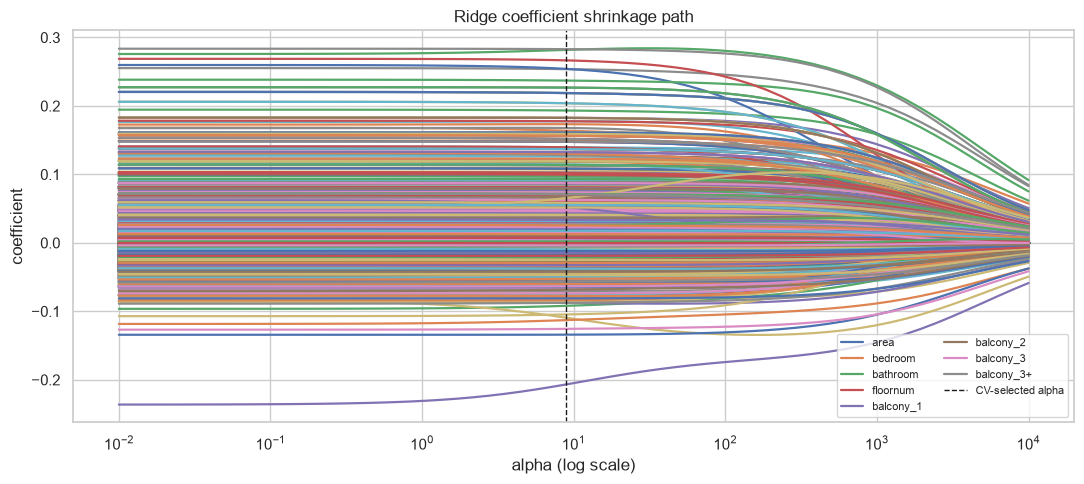

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
coef_path = []
Xs = StandardScaler().fit_transform(X_train)
for a in alphas:
    coef_path.append(Ridge(alpha=a).fit(Xs, y_train).coef_)
coef_path = np.array(coef_path)
plt.figure(figsize=(11, 5))
for i, col in enumerate(X.columns):
    plt.plot(alphas, coef_path[:, i], lw=1.6, label=col if i < 8 else None)
plt.xscale("log")
plt.axvline(ridge_alpha, color="k", ls="--", lw=1, label="CV-selected alpha")
plt.xlabel("alpha (log scale)")
plt.ylabel("coefficient")
plt.title("Ridge coefficient shrinkage path")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()